# Ximenez Extract Topics

In [101]:
from lxml import etree
import pandas as pd

In [221]:
ns = {'tei':"http://www.tei-c.org/ns/1.0"}
xml_src = "xom-all-flat-mod-pnums.xml"
xml_str = open(xml_src, 'rb').read()
tree = etree.parse(xml_src)
root = tree.getroot()

In [300]:
paras = root.xpath("//tei:div[@xml:lang='quc']//tei:p", namespaces=ns)

In [ ]:
para_list = []
for i, para in enumerate(paras):

    para2 = []
    for el in para.iter():
        para2.append(el.text.strip()) if el.text else None
        para2.append(el.tail.strip()) if el.tail else None

    
    para3 = " ".join(para2)
    para3 = para3.replace(" –  ", "")
    para_list.append(para3)
            

In [307]:
pd.DataFrame(para_list)

,0
0,cap. 1.del serde Díos ARE V XE OHER Ꜩih ...
1,V aral xchicaꜩibah vi xchica 1. tiquiba vi o...
2,"ARE V ꜨIHOXIC VAE Cacaꜩinin oc, caca chamam..."
3,V ae cute nabe ꜩih nabe vchan. mahabi oꜫ hun...
4,T a xpe cut vꜩih varal xul cuq ri tepeu gucu...
...,...
150,ucabahau hun L olmet ahau vnimha
151,roxahau hun N im chocoh ahau unimha.
152,cut vcah ahau hun H acaviꜩ vnim ha chicahibc...
153,A re curi e oxib chi nim chocoh queheri e c...


In [315]:
rses = root.xpath("//tei:div[@xml:lang='quc']//tei:rs", namespaces=ns)

In [316]:
rses[2].get('ana').strip()

"TZ'AQOL"

In [320]:
TEMA_SEQ = pd.DataFrame([rs.get("ana").strip().lower() for rs in rses], columns=['ana_id'])

In [321]:
TEMA = TEMA_SEQ.ana_id.value_counts().to_frame('n')

In [426]:
W = TEMA[TEMA.n > 5].index

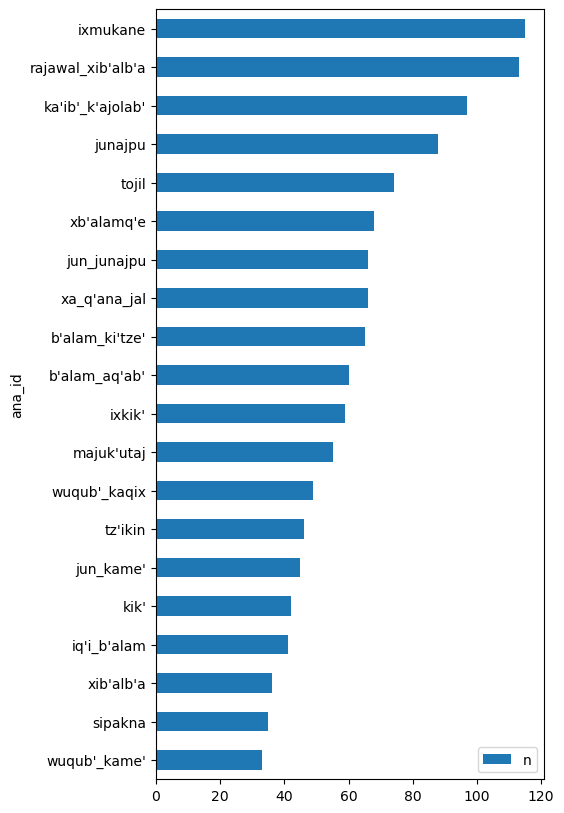

In [324]:
TEMA.head(20).sort_values('n').plot.barh(figsize=(5,10), rot=0);

In [395]:
import seaborn as sns
import matplotlib.pyplot as plt

In [396]:
sns.set()

In [428]:
X = TEMA_SEQ.reset_index().sort_values('index')

KeyError: "None of [Index(['ixmukane', 'rajawal_xib'alb'a', 'ka'ib'_k'ajolab'', 'junajpu', 'tojil',\n       'xb'alamq'e', 'jun_junajpu', 'xa_q'ana_jal', 'b'alam_ki'tze'',\n       'b'alam_aq'ab'',\n       ...\n       'pisom_q'aq'al', 'ixb'aqiyalo', 'chimalmat', 'tukur', 'jun_winaq',\n       'k'otal', 'jun_kame'_wuqub'_kame'', 'sotz'i_ja', 'b'alam_ja',\n       'pusb'al_chaaj'],\n      dtype='object', name='ana_id', length=119)] are in the [columns]"

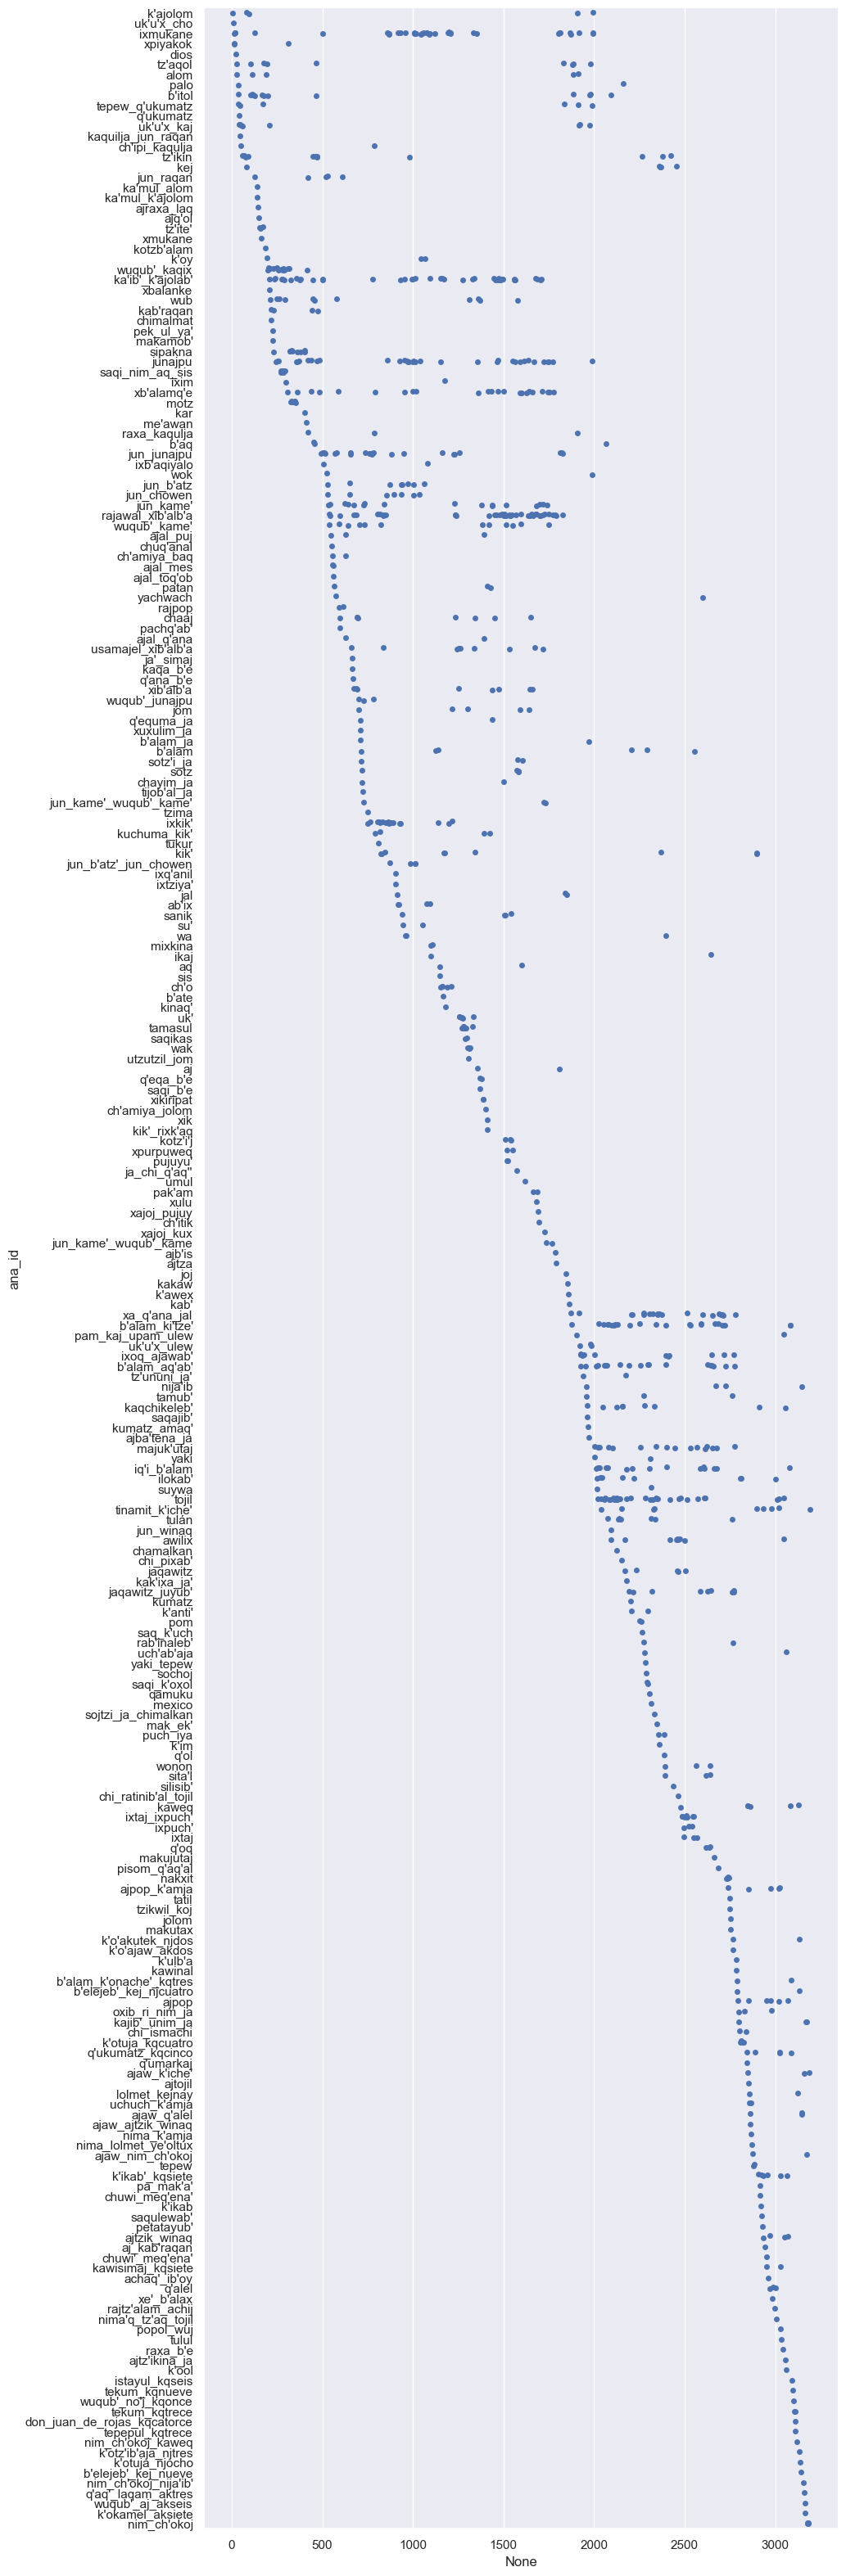

In [423]:
fig, ax = plt.subplots(figsize=(10, 40))
sns.stripplot(x=X.index, y=X.ana_id, ax=ax);